# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Loading Dataset

In [2]:
df = pd.read_csv('train.csv')

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

# Data Cleaning

In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
df.fillna(0, inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


# Feature Engineering

In [7]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

# Exploratory Data Analysis

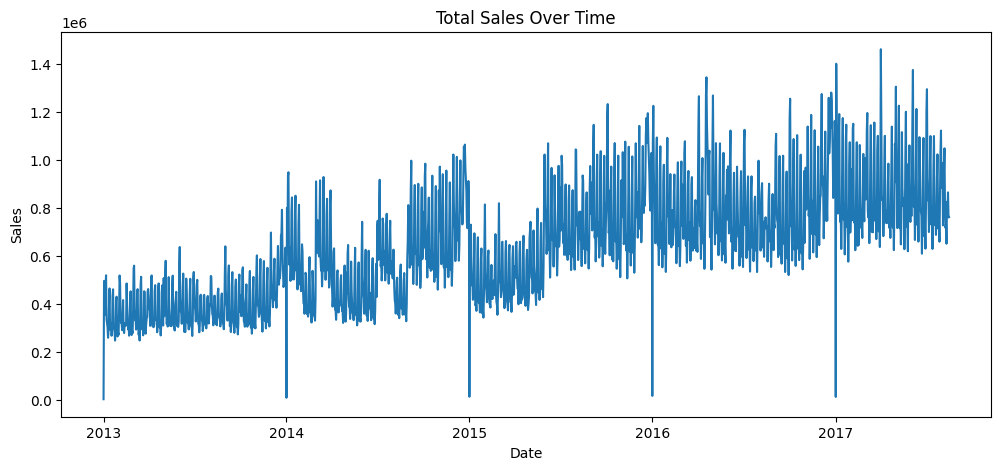

In [8]:
sales_trend = df.groupby('date')['sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_trend)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Preparing Data for ML

In [9]:
features = ['store_nbr','onpromotion','year','month','day','dayofweek']
X = df[features]
y = df['sales']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

# Train Forecast Model

In [11]:
model = RandomForestRegressor(n_estimators=100)

model.fit(X_train, y_train)

RandomForestRegressor()

# Predictions and Evaluation

In [12]:
predictions = model.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 490.24871574676956
RMSE: 1100.4688703652996


# Visualization

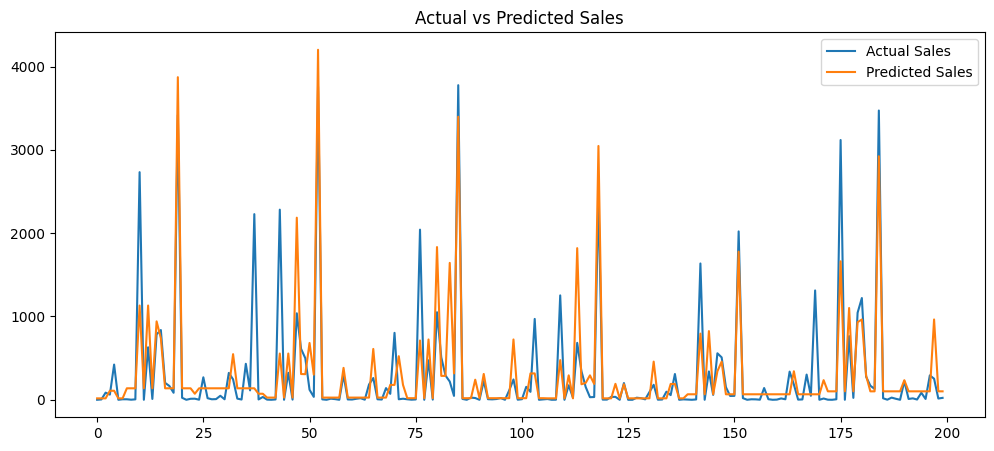

In [14]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Actual Sales")
plt.plot(predictions[:200], label="Predicted Sales")

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

# Future Forecast

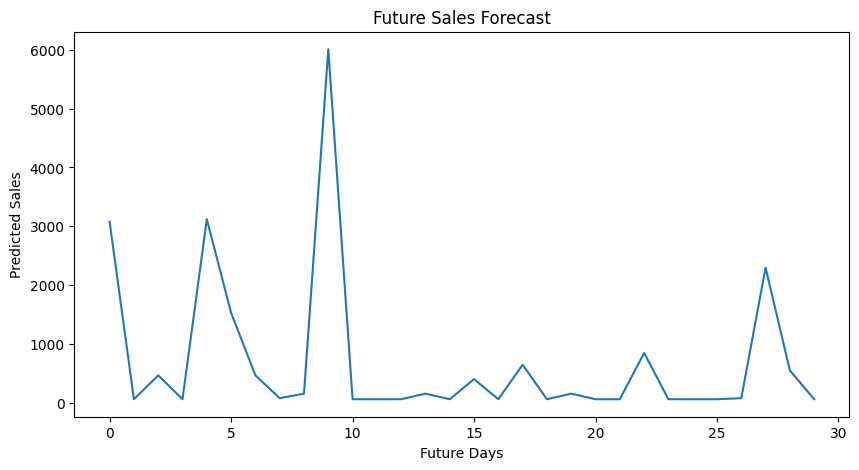

In [15]:
future = X_test.tail(30)

future_predictions = model.predict(future)

plt.figure(figsize=(10,5))
plt.plot(future_predictions)
plt.title("Future Sales Forecast")
plt.xlabel("Future Days")
plt.ylabel("Predicted Sales")
plt.show()